# Media Coverage vs Humanitarian Funding

Does media attention correlate with how well a humanitarian crisis is funded?

This notebook loads daily GDELT media coverage data for ~104 crisis countries, computes annual averages, and compares them against CERF/CBPF pooled-fund coverage from `country_year_severity_funding.csv`.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy import stats

DATA_DIR = Path("data")
MEDIA_DIR = DATA_DIR / "media"

In [2]:
# Load all per-country media CSVs into a single DataFrame
frames = []
for path in sorted(MEDIA_DIR.glob("*.csv")):
    iso3 = path.stem
    df = pd.read_csv(path, parse_dates=["date"])
    df["date"] = pd.to_datetime(df["date"], utc=True)
    df["Country_ISO3"] = iso3
    frames.append(df)

if not frames:
    raise RuntimeError("No media CSVs found in data/media/. Run scripts/prefetch_media.py first.")

media_all = pd.concat(frames, ignore_index=True)
print(f"{len(frames)} countries, {len(media_all):,} total rows")
media_all.head()

104 countries, 188,230 total rows


,date,articles,frac,Country_ISO3
0,2021-01-01 00:00:00+00:00,825,0.009773,AFG
1,2021-01-02 00:00:00+00:00,805,0.011061,AFG
2,2021-01-03 00:00:00+00:00,682,0.009456,AFG
3,2021-01-04 00:00:00+00:00,1968,0.015008,AFG
4,2021-01-05 00:00:00+00:00,939,0.006123,AFG


In [7]:
# Average media coverage per country per year
media_all["Year"] = media_all["date"].dt.year

media_annual = (
    media_all
    .groupby(["Country_ISO3", "Year"])["frac"]
    .mean()
    .reset_index()
)
media_annual["media_frac_pct"] = media_annual["frac"] * 100  # match media.py convention

print(f"{media_annual['Country_ISO3'].nunique()} countries, years {media_annual['Year'].min()}–{media_annual['Year'].max()}")
media_annual.sort_values("Country_ISO3", ascending=False).head(15)

104 countries, years 2021–2026


,Country_ISO3,Year,frac,media_frac_pct
599,ZWE,2026,0.002777,0.277743
598,ZWE,2025,0.002506,0.250613
597,ZWE,2024,0.003142,0.314250
596,ZWE,2023,0.003203,0.320296
595,ZWE,2022,0.003166,0.316641
594,ZWE,2021,0.003822,0.382215
593,ZMB,2026,0.000850,0.085007
592,ZMB,2025,0.000828,0.082784
591,ZMB,2024,0.000989,0.098894
590,ZMB,2023,0.001225,0.122523


In [8]:
media_annual.describe()

,Year,frac,media_frac_pct
count,600.000000,600.000000,600.000000
mean,2023.540000,0.004704,0.470409
std,1.716579,0.009950,0.995011
min,2021.000000,0.000000,0.000000
25%,2022.000000,0.000869,0.086885
50%,2024.000000,0.001635,0.163486
75%,2025.000000,0.004728,0.472774
max,2026.000000,0.082148,8.214794


In [4]:
# Load funding data
funding_df = pd.read_csv(DATA_DIR / "country_year_severity_funding.csv")
funding_df.columns = funding_df.columns.str.strip()
for col in ["Pct_Funded", "Total_Actual_Funding", "Funding_Gap", "revisedRequirements", "INFORM Severity Index"]:
    funding_df[col] = pd.to_numeric(funding_df[col], errors="coerce")

print(f"{funding_df.shape[0]} rows, {funding_df['Country_ISO3'].nunique()} countries")
funding_df.head()

346 rows, 71 countries


,Country_ISO3,Year,revisedRequirements,INFORM Severity Index,Plan_Count,CERF_Funding,CBPF_Budget,Total_Actual_Funding,Funding_Gap,Pct_Funded
0,SYR,2020,4617532832,4.9,4,54883071.0,68737943.05,1.236210e+08,4.493912e+09,2.68
1,AFG,2020,1931050820,4.6,4,27999965.0,74274515.41,1.022745e+08,1.828776e+09,5.30
2,YEM,2020,8452043406,4.6,5,64999937.0,99093834.22,1.640938e+08,8.287950e+09,1.94
3,COD,2020,5738269640,4.5,4,69931007.0,0.00,6.993101e+07,5.668339e+09,1.22
4,SDN,2020,9733612516,4.5,4,103374841.0,75791589.60,1.791664e+08,9.554446e+09,1.84


In [5]:
# Merge media coverage with funding data
merged = media_annual.merge(funding_df, on=["Country_ISO3", "Year"], how="inner")
print(f"{len(merged)} matched rows — {merged['Country_ISO3'].nunique()} countries, years {merged['Year'].min()}–{merged['Year'].max()}")
merged[["Country_ISO3", "Year", "media_frac_pct", "Pct_Funded", "Total_Actual_Funding", "INFORM Severity Index"]].head(10)

274 matched rows — 69 countries, years 2021–2025


,Country_ISO3,Year,media_frac_pct,Pct_Funded,Total_Actual_Funding,INFORM Severity Index
0,AFG,2021,1.888205,17.50,2.581289e+08,4.7
1,AFG,2022,1.041857,3.29,2.926707e+08,4.5
2,AFG,2023,0.726396,2.92,1.885800e+08,4.4
3,AFG,2024,0.554935,1.80,5.521333e+07,4.4
4,AFG,2025,0.592827,2.37,1.147979e+08,4.5
5,AGO,2021,0.092561,0.94,4.999561e+06,3.2
6,AGO,2022,0.088374,1.01,6.000000e+06,3.1
7,AGO,2023,0.077147,0.00,0.000000e+00,3.2
8,AGO,2024,0.078812,0.45,2.997820e+06,2.7
9,AGO,2025,0.073860,0.23,1.799874e+06,3.2


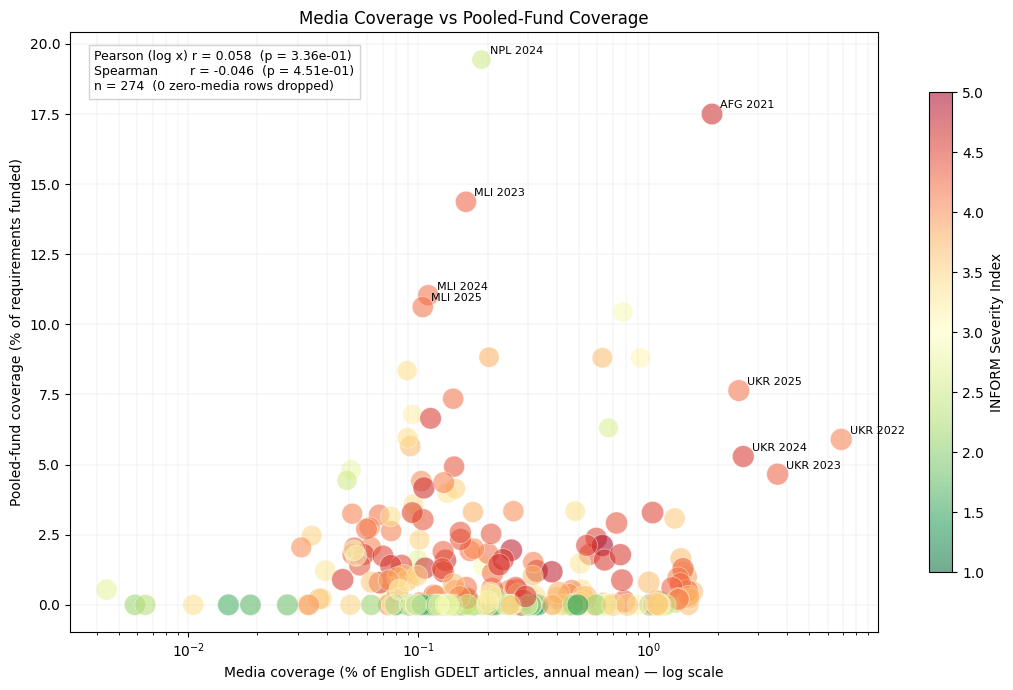

In [9]:
fig, ax = plt.subplots(figsize=(11, 7))

valid = merged.dropna(subset=["media_frac_pct", "Pct_Funded", "INFORM Severity Index", "revisedRequirements"]).copy()

# Filter out exact zeros on x for log scale; keep them as a separate rug/strip if you want
valid_pos = valid[valid["media_frac_pct"] > 0].copy()
n_dropped = len(valid) - len(valid_pos)

sizes = np.log1p(valid_pos["revisedRequirements"]) / np.log1p(valid_pos["revisedRequirements"]).max() * 250 + 20

sc = ax.scatter(
    valid_pos["media_frac_pct"],
    valid_pos["Pct_Funded"],
    c=valid_pos["INFORM Severity Index"],
    s=sizes,
    cmap="RdYlGn_r",
    vmin=1, vmax=5,
    alpha=0.55,
    edgecolors="white",
    linewidth=0.5,
)
cbar = fig.colorbar(sc, ax=ax, shrink=0.8)
cbar.set_label("INFORM Severity Index")

ax.set_xscale("log")
ax.set_xlabel("Media coverage (% of English GDELT articles, annual mean) — log scale")
ax.set_ylabel("Pooled-fund coverage (% of requirements funded)")

# Correlation on log-transformed x to match the visual
r_p, p_p = stats.pearsonr(np.log10(valid_pos["media_frac_pct"]), valid_pos["Pct_Funded"])
r_s, p_s = stats.spearmanr(valid_pos["media_frac_pct"], valid_pos["Pct_Funded"])
ax.text(
    0.03, 0.97,
    f"Pearson (log x) r = {r_p:.3f}  (p = {p_p:.2e})\n"
    f"Spearman        r = {r_s:.3f}  (p = {p_s:.2e})\n"
    f"n = {len(valid_pos)}  ({n_dropped} zero-media rows dropped)",
    transform=ax.transAxes, va="top", fontsize=9,
    bbox=dict(facecolor="white", alpha=0.85, edgecolor="#ccc"),
)

# Label country-years that are outliers in either dimension, deduplicated
candidates = pd.concat([
    valid_pos.nlargest(5, "media_frac_pct"),
    valid_pos.nlargest(5, "Pct_Funded"),
]).drop_duplicates(subset=["Country_ISO3", "Year"])

for _, row in candidates.iterrows():
    ax.annotate(
        f"{row['Country_ISO3']} {int(row['Year'])}",
        (row["media_frac_pct"], row["Pct_Funded"]),
        textcoords="offset points", xytext=(6, 4), fontsize=8,
    )

ax.set_title("Media Coverage vs Pooled-Fund Coverage")
ax.grid(True, which="both", linewidth=0.3, alpha=0.4)
plt.tight_layout()
plt.show()